Text to Image generation pipeline



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- Pipeline Components ---
Text Encoder: <class 'transformers.models.clip.modeling_clip.CLIPTextModel'>
VAE: <class 'diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL'>
U-Net: <class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>


  0%|          | 0/30 [00:00<?, ?it/s]

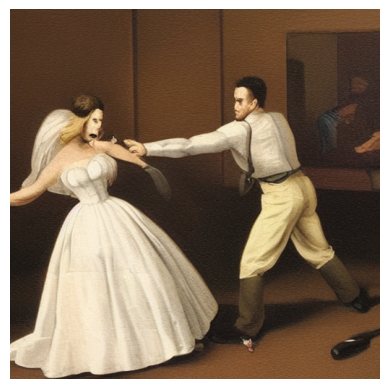

In [3]:
import torch
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler
import matplotlib.pyplot as plt

# 1. Load the model
model_id = "runwayml/stable-diffusion-v1-5"

# 2. We can swap the 'Scheduler'.
# Euler is faster and often produces sharper images than the default.
scheduler = EulerDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    scheduler=scheduler,
    torch_dtype=torch.float16
).to("cuda")

# 3. Accessing the internal "Brain" of the pipeline
print(f"--- Pipeline Components ---")
print(f"Text Encoder: {type(pipe.text_encoder)}") # The part that understands English
print(f"VAE: {type(pipe.vae)}")                   # The part that draws the actual pixels
print(f"U-Net: {type(pipe.unet)}")               # The part that removes the noise

# 4. Generate with the new scheduler
prompt = "two married couple having a fight, detailed"
image = pipe(prompt, num_inference_steps=30).images[0]

plt.imshow(image)
plt.axis("off")
plt.show()